In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from aux_func import get_data

In [2]:
code_to_state = {33: 'RJ', 32: 'ES', 41: 'PR', 23: 'CE', 21: 'MA',
 31: 'MG', 42: 'SC', 26: 'PE', 25: 'PB', 24: 'RN', 22: 'PI', 27: 'AL',
 28: 'SE', 35: 'SP', 43: 'RS', 15: 'PA', 16: 'AP', 14: 'RR',  11: 'RO',
 13: 'AM', 12: 'AC', 51: 'MT', 50: 'MS', 52: 'GO', 17: 'TO', 53: 'DF',
 29: 'BA'}

state_to_code = {value: key for key, value in code_to_state.items()}

geo_dengue = [2931350,2933307,2302503,3119401,
              3549805,3541406,1200401,1200203,
              1716109,4113700,4103701,4104808,
              5201405,5102637,5215231]

geo_chik = [2211001,2931350,3143302,3119401,
            1721000,1716109,4104808,4219507,
            5103403,5102637] 

In [3]:
df_dengue_state, df_dengue_city  = get_data(disease = 'dengue')
df_chik_state, df_chik_city  = get_data(disease = 'chikungunya')

In [74]:
challenge = 'chik_state'
model = '3rd_imdc_purdue_neuralearth'

df_preds = pd.read_csv(f'./predictions/{challenge}_{model}.csv.gz')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis
0,2022-10-09,0.0,0.0,0.0,0.0,0.557164,1.364428,4.380373,12.125337,25.194917,12,11034,1,0.771009
1,2022-10-16,0.0,0.0,0.0,0.0,0.681812,1.478322,4.383787,12.346559,29.112664,12,11034,1,0.771009
2,2022-10-23,0.0,0.0,0.0,0.0,0.663573,1.451887,4.366839,12.918127,27.735736,12,11034,1,0.771009
3,2022-10-30,0.0,0.0,0.0,0.0,0.676428,1.450470,4.322901,13.009932,29.352181,12,11034,1,0.771009
4,2022-11-06,0.0,0.0,0.0,0.0,0.605140,1.618693,4.439754,12.462216,29.531013,12,11034,1,0.771009


In [75]:
if ('state' in challenge) & ('dengue' in challenge):
    df_data = df_dengue_state 
    col = 'adm_1'
    disease = 'dengue'

if ('city' in challenge) & ('dengue' in challenge):
    df_data = df_dengue_city
    col = 'adm_2'
    disease = 'dengue'


if ('state' in challenge) & ('chik' in challenge):
    df_data = df_chik_state
    col = 'adm_1'
    disease = 'chik'



if ('city' in challenge) & ('chik' in challenge):
    df_data = df_chik_city
    col = 'adm_2'
    disease = 'chik'


df_data.date = pd.to_datetime(df_data.date)
    

In [76]:
df_preds_agg = df_preds.merge(df_data, on = ['date', col])

In [77]:
def plot_model(df_preds_agg, region): 

    df_preds_f = df_preds_agg.loc[df_preds_agg[col] == region]

    _, ax = plt.subplots(2, 2, figsize = (10, 5))

    for ax_, val in zip(ax.ravel(), [1,2,3,4]): 

        df_ = df_preds_f.loc[df_preds_f.validation == val]

        ax_.plot(df_.date, df_.pred, color = 'tab:orange')
        ax_.fill_between(df_.date, df_.lower_90, df_.upper_90, color = 'tab:orange', alpha = 0.1)

        ax_.plot(df_.date, df_.casos, color = 'black', marker = '.', zorder = 0)
        ax_.grid()

    plt.tight_layout()
    try: 
        plt.suptitle(f'{disease} - {code_to_state[region]}', y = 1.05)
    except: 
        plt.suptitle(f'{disease} - {region}', y = 1.05)

    plt.show()

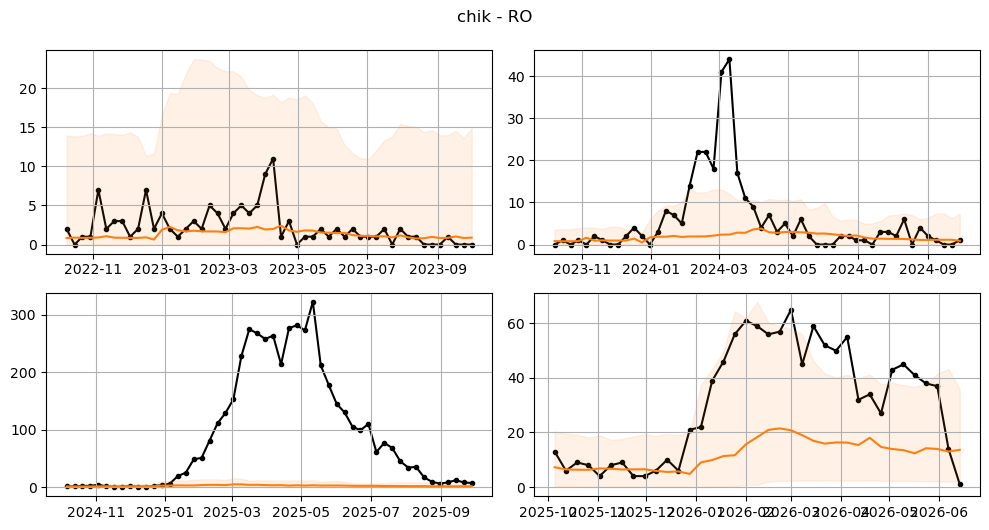

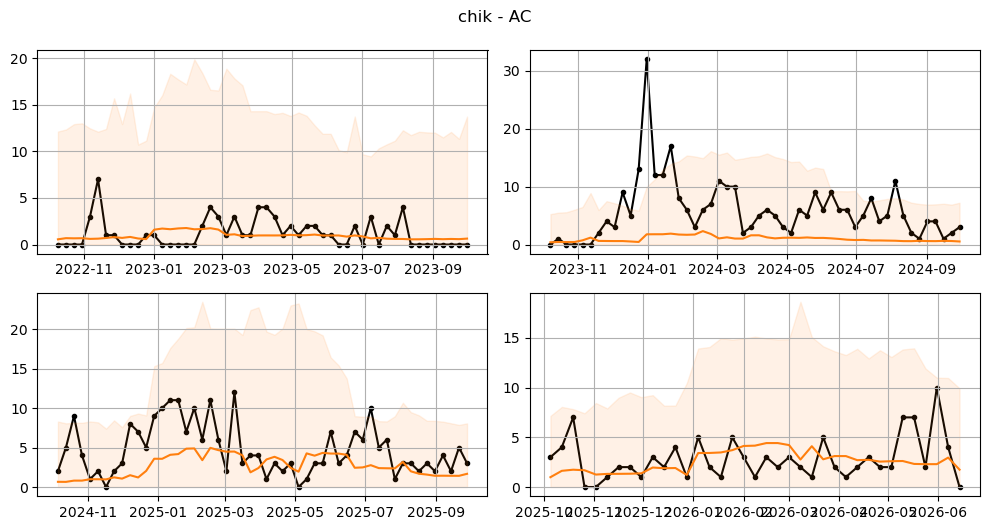

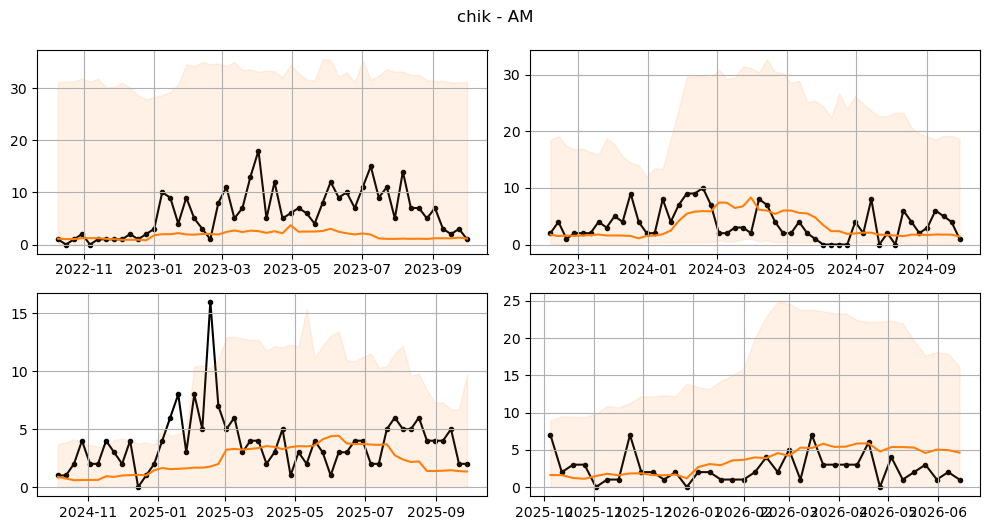

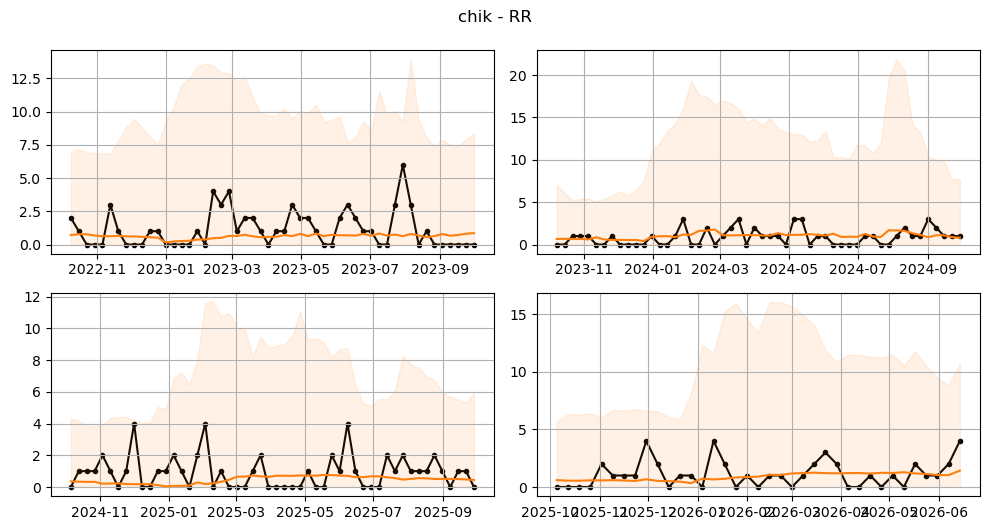

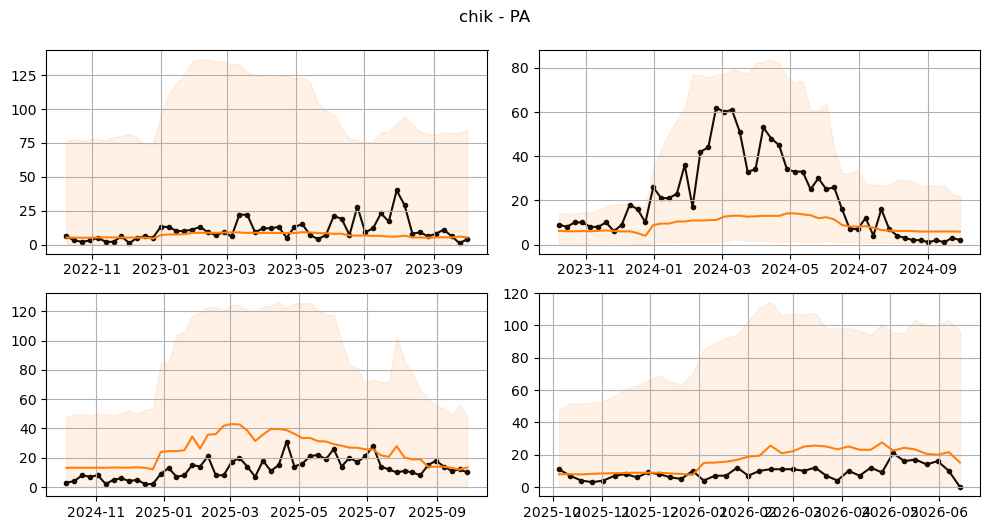

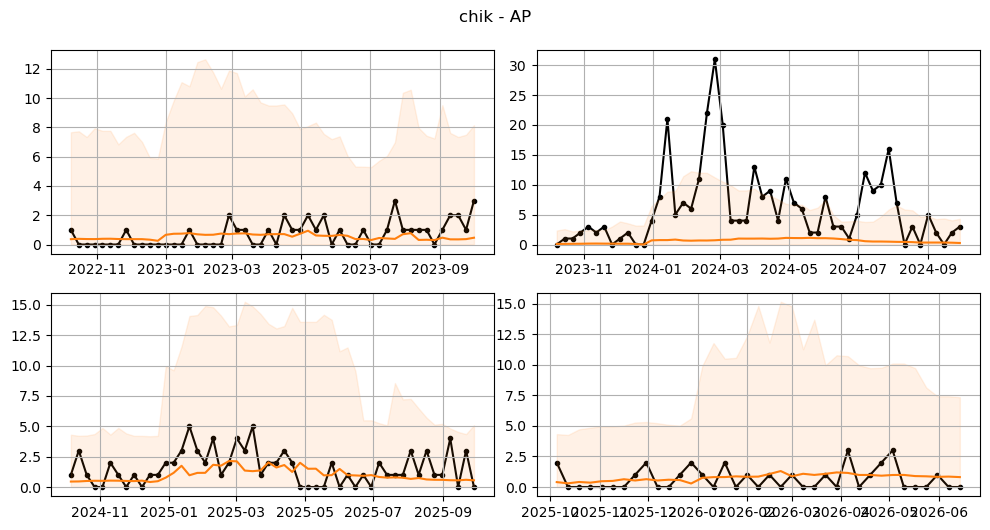

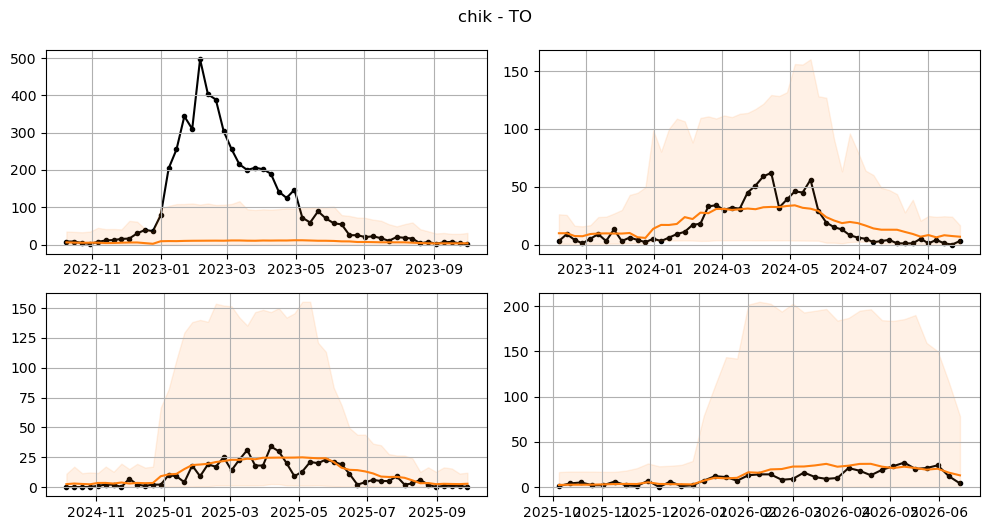

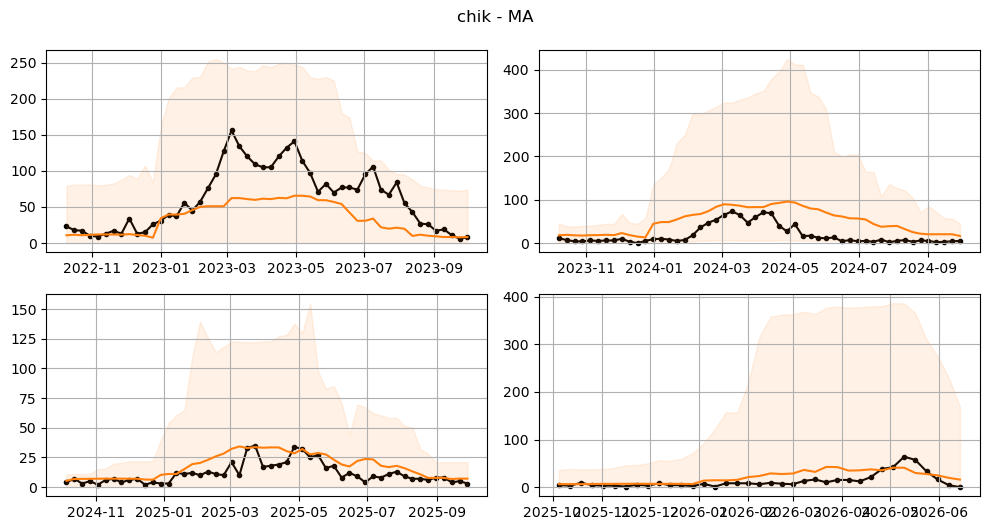

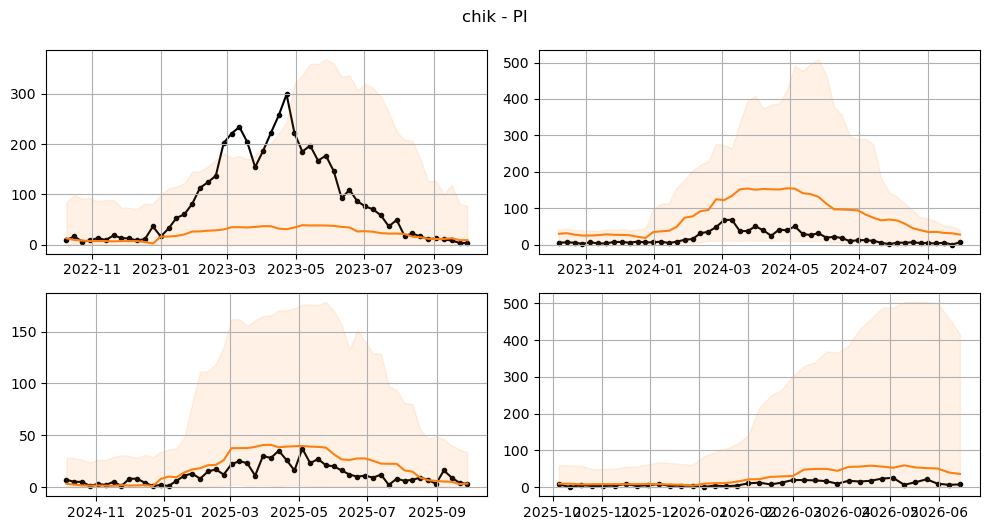

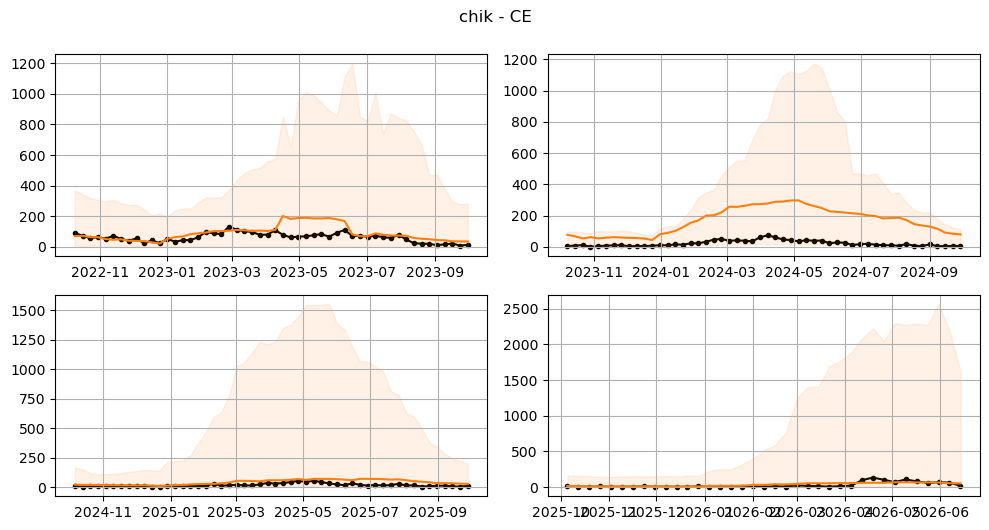

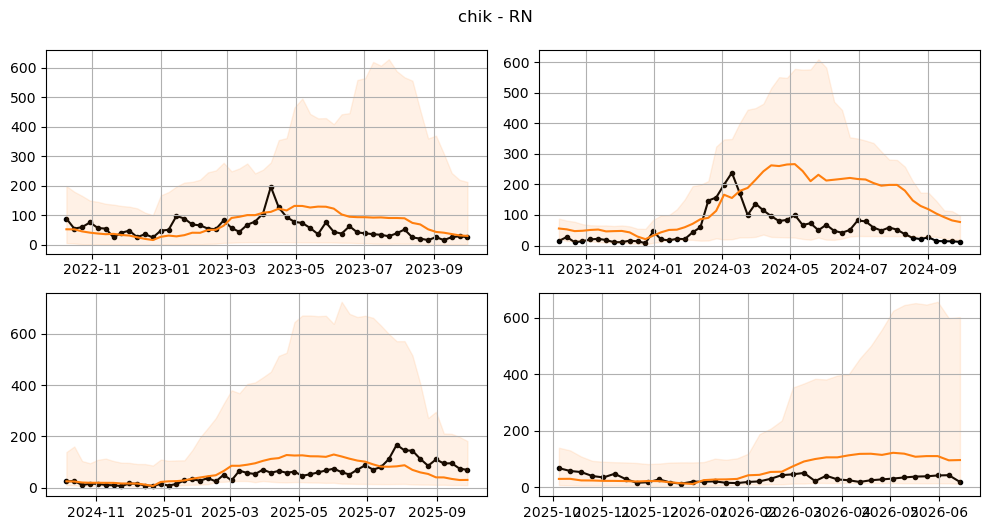

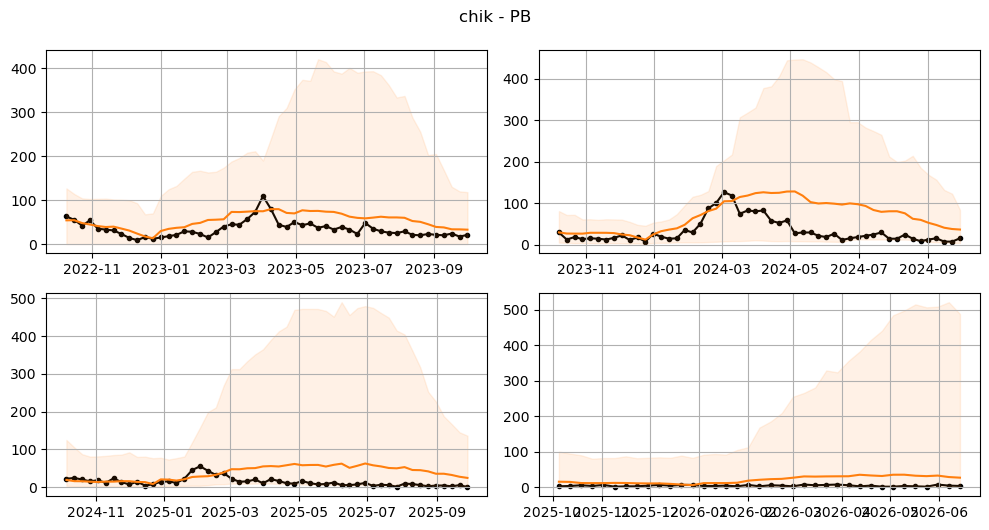

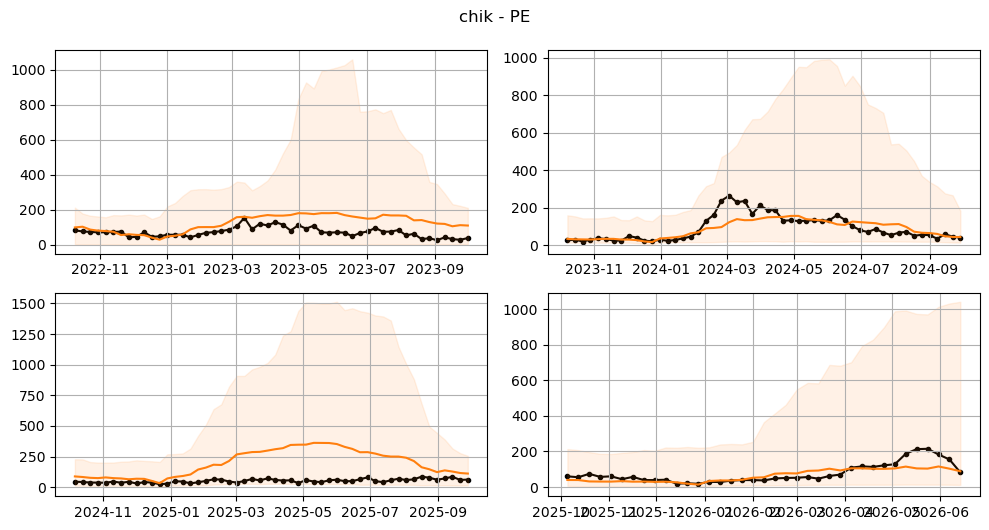

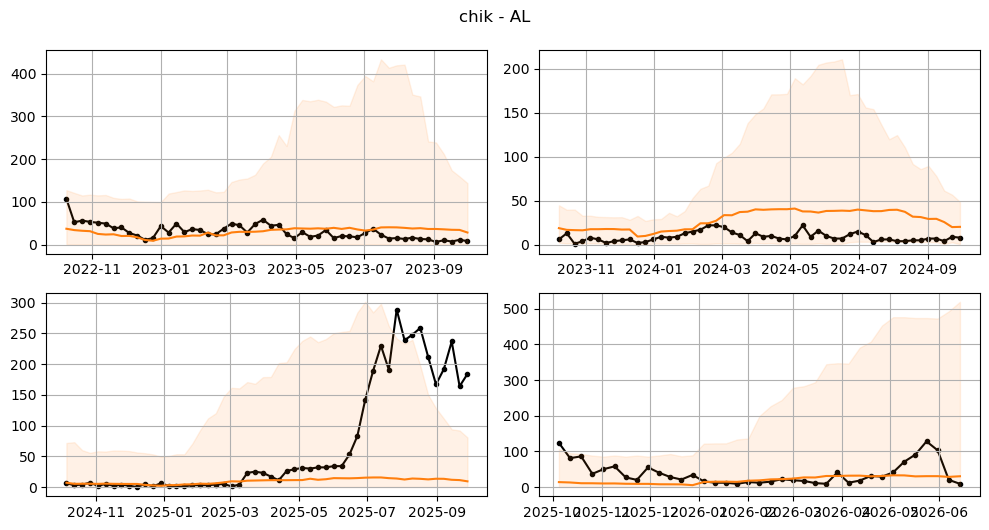

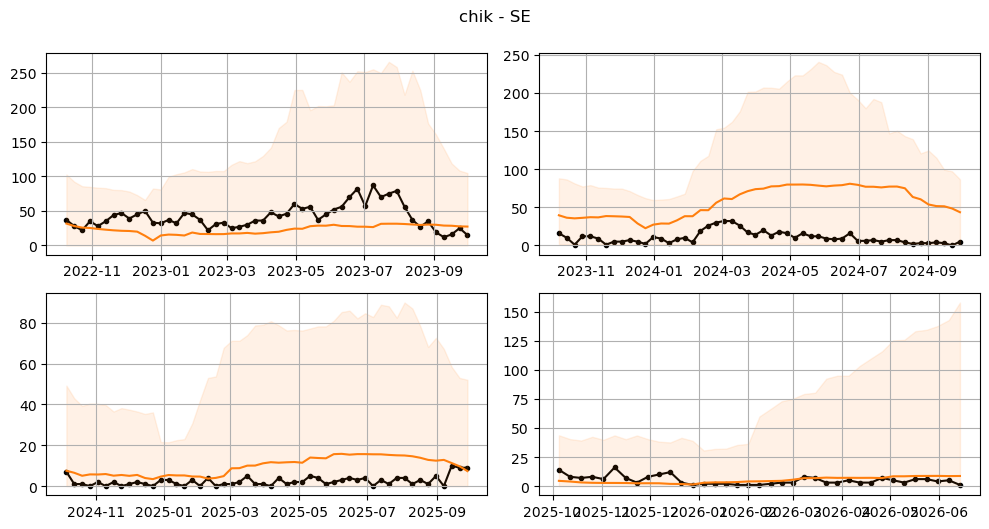

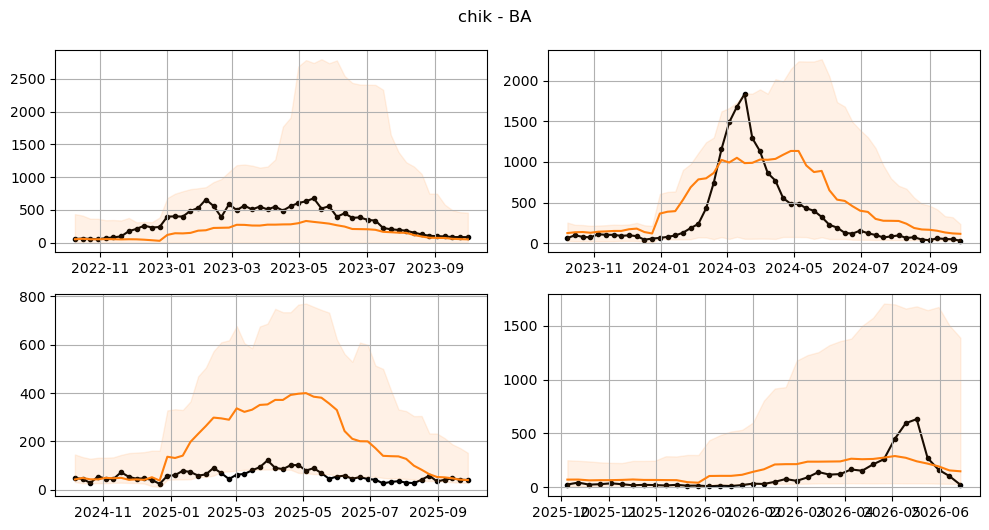

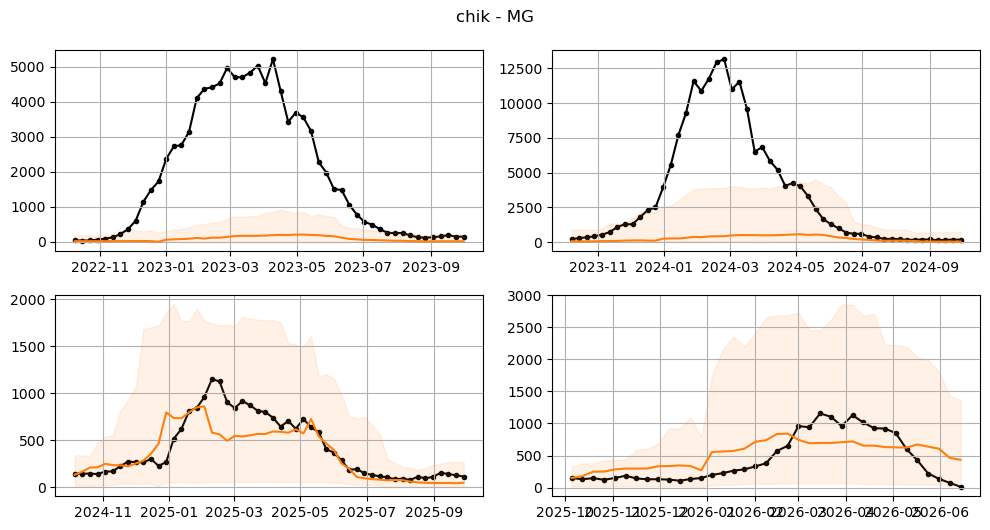

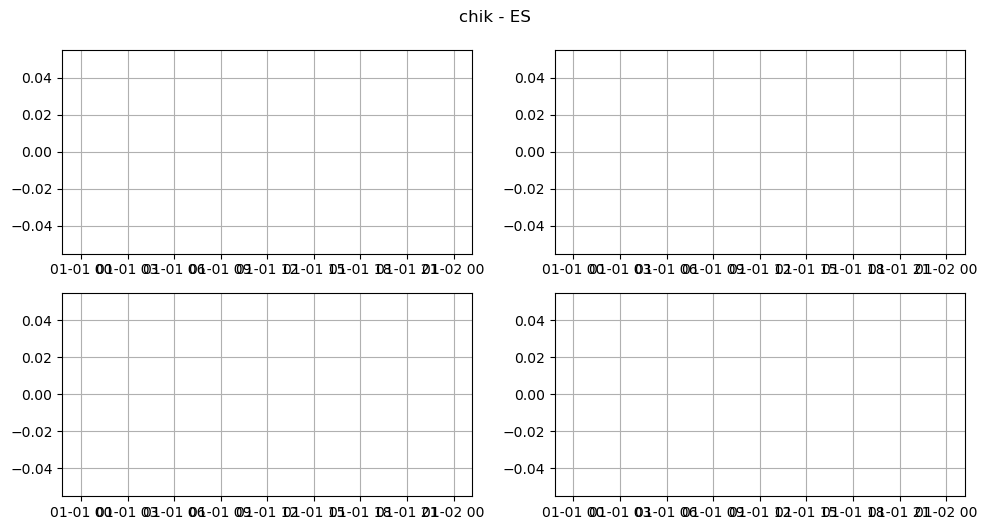

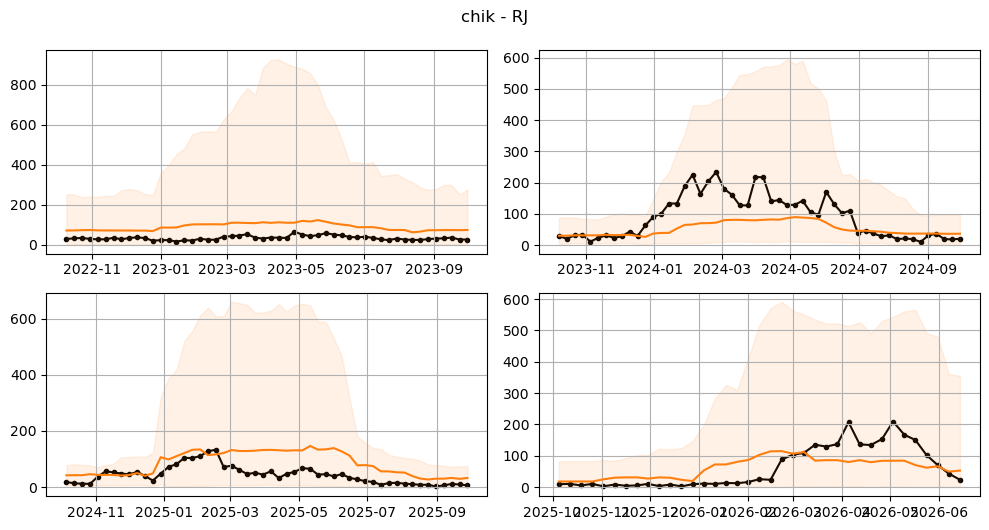

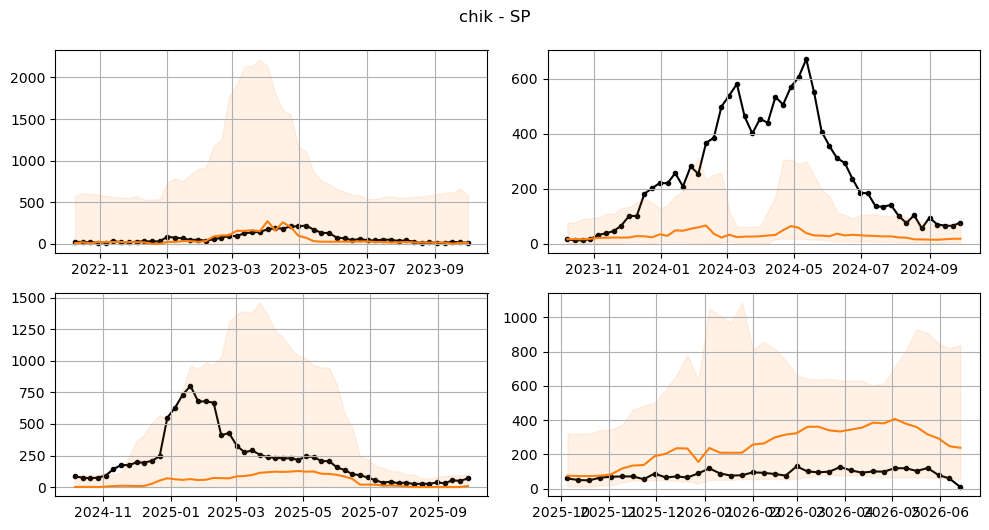

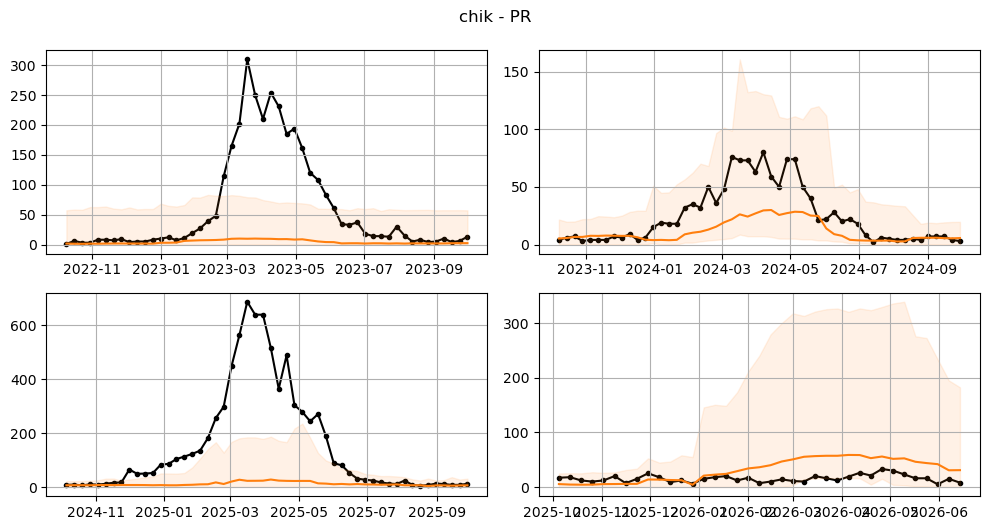

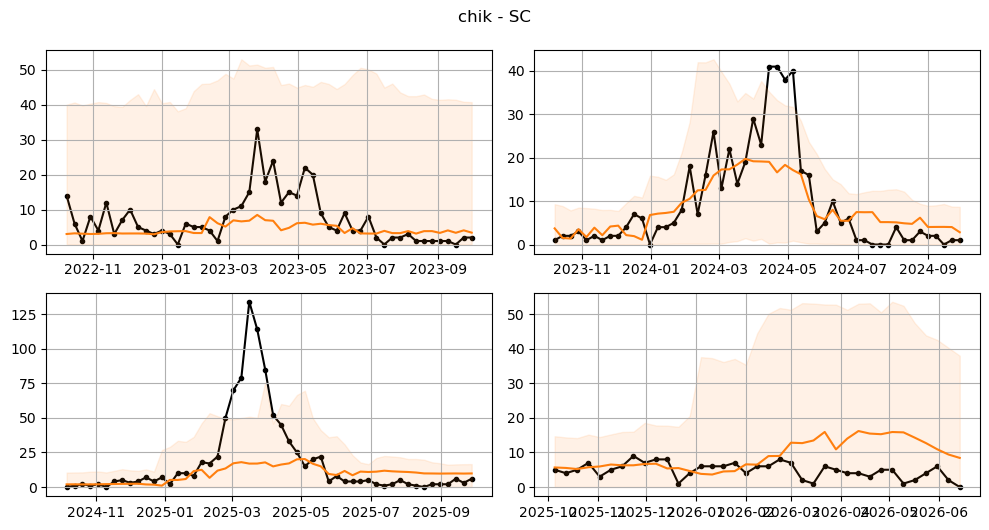

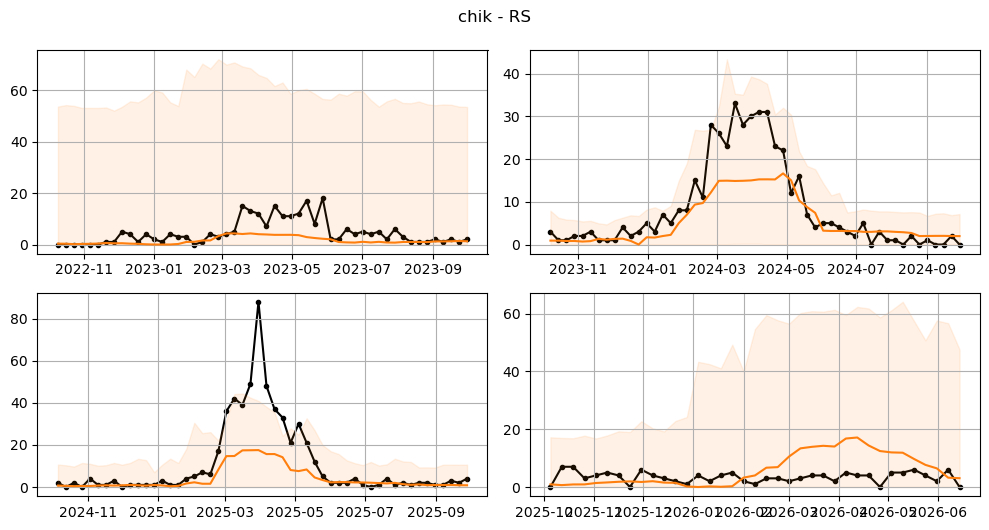

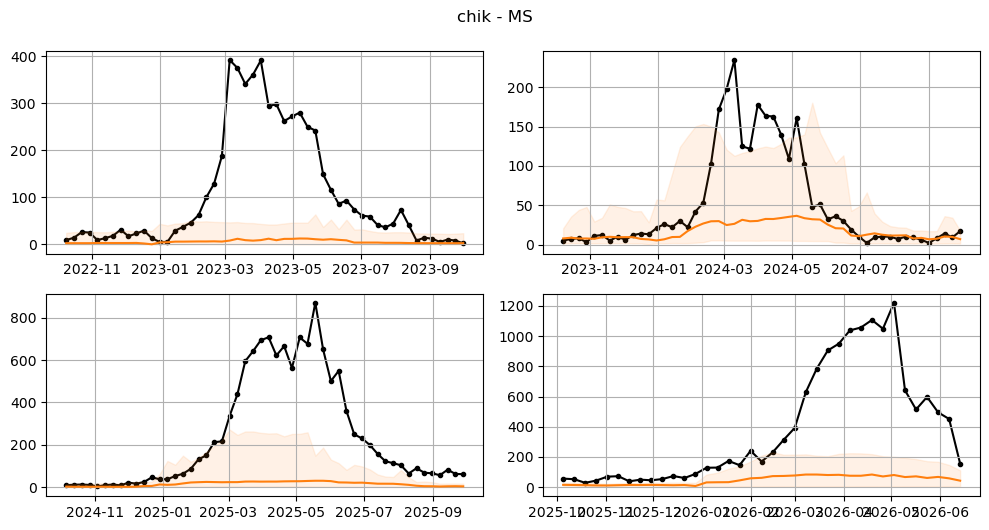

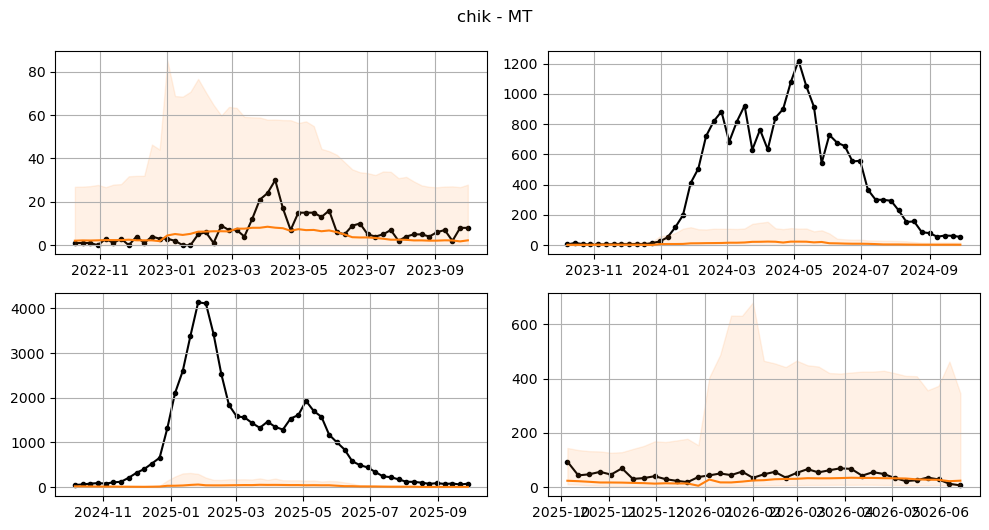

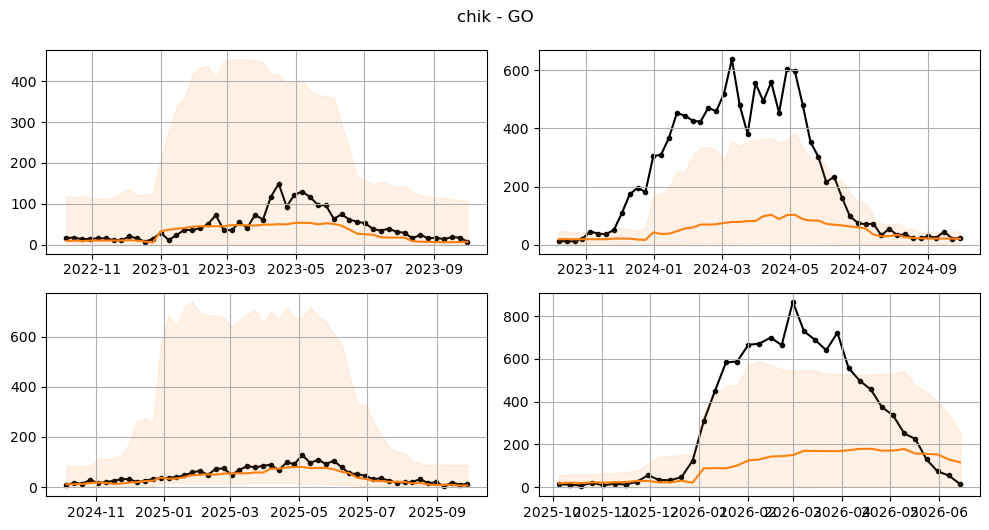

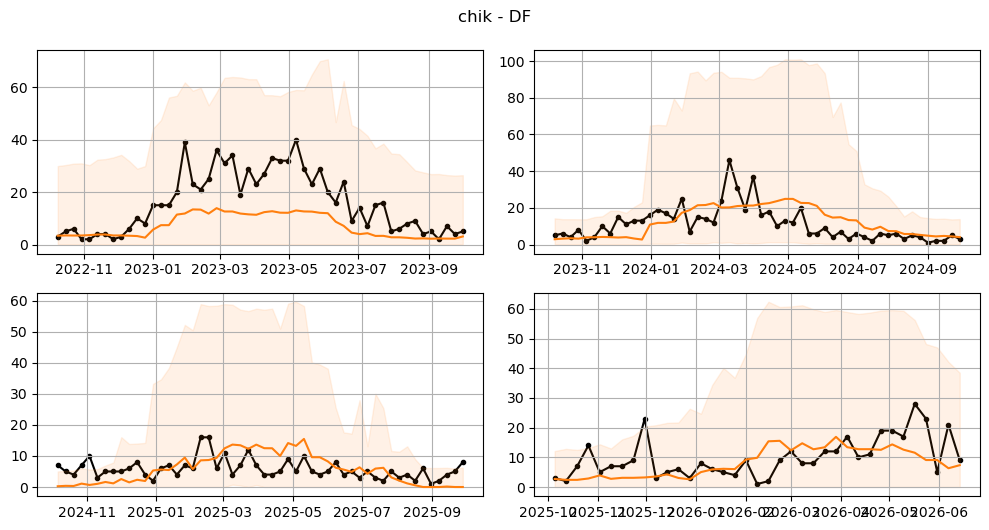

In [78]:
for reg in df_data[col].unique():  

    plot_model(df_preds_agg, region= reg)

    plt.close()